In [2]:
from diffusers import DiffusionPipeline
from IPython.display import Image as IPImage, display
from time import time
import torch

model_name = "Qwen/Qwen-Image-2512"

# Load the pipeline
if torch.cuda.is_available():
    torch_dtype = torch.bfloat16
    device = "cuda"
else:
    torch_dtype = torch.float32
    device = "cpu"
pipe = DiffusionPipeline.from_pretrained(model_name,torch_dtype=torch_dtype).to(device)
aspect_ratios = {
    "1:1": (1328, 1328),
    "16:9": (1664, 928),
    "9:16": (928, 1664),
    "4:3": (1472, 1104),
    "3:4": (1104, 1472),
    "3:2": (1584, 1056),
    "2:3": (1056, 1584),
}

/home/admin/_github/massimodipaolo/ai-crash-course/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:283: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  warnings.warn(


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

2026-01-10 14:25:13.881949564 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


Loading checkpoint shards:   0%|          | 0/9 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [35]:
def _generate(prompt,negative_prompt=None,aspect_ratio="1:1",image_path=None):
    start_time = time()
    width, height = aspect_ratios[aspect_ratio]
    scale = .5 #reduce size for faster generation
    _pipe = pipe(
        prompt=prompt,
        width=int(width * scale),
        height=int(height * scale),
        negative_prompt=negative_prompt,
        true_cfg_scale=4.0,
        num_inference_steps=75,
        generator=torch.Generator(device=device).manual_seed(42)
    )
    image = _pipe.images[0]
    image.save(image_path)
    display(IPImage(filename=image_path))
    print(f"Image saved to {image_path}")
    end_time = time()
    print(f"Generation took {end_time - start_time:.2f} seconds")

`height` and `width` have to be divisible by 16 but are 664 and 664. Dimensions will be resized accordingly
true_cfg_scale is passed as 4.0, but classifier-free guidance is not enabled since no negative_prompt is provided.


  0%|          | 0/50 [00:00<?, ?it/s]

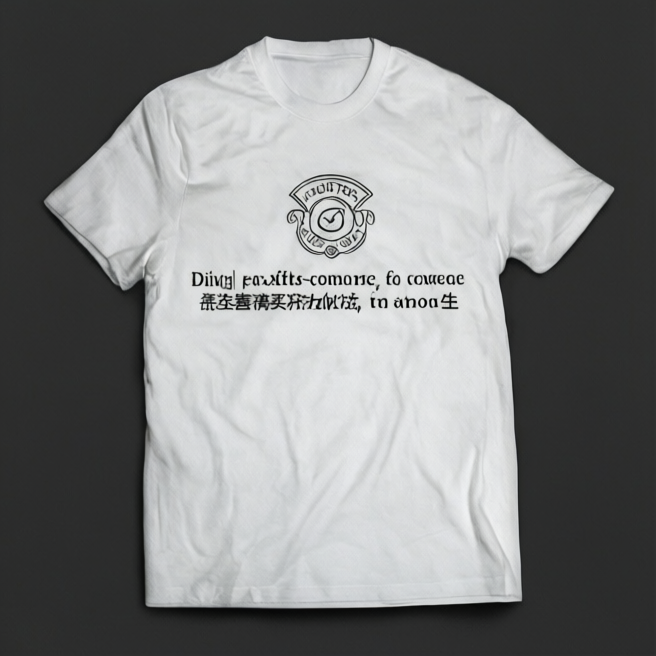

Image saved to ./tmp/5-p-1.png
Generation took 48.39 seconds


In [4]:
#naive prompt
prompt = "A t-shirt with a logo for a DIY crafts e-commerce website."
_generate(prompt=prompt,image_path="./tmp/5-p-1.png")

`height` and `width` have to be divisible by 16 but are 664 and 664. Dimensions will be resized accordingly
true_cfg_scale is passed as 4.0, but classifier-free guidance is not enabled since no negative_prompt is provided.


  0%|          | 0/50 [00:00<?, ?it/s]

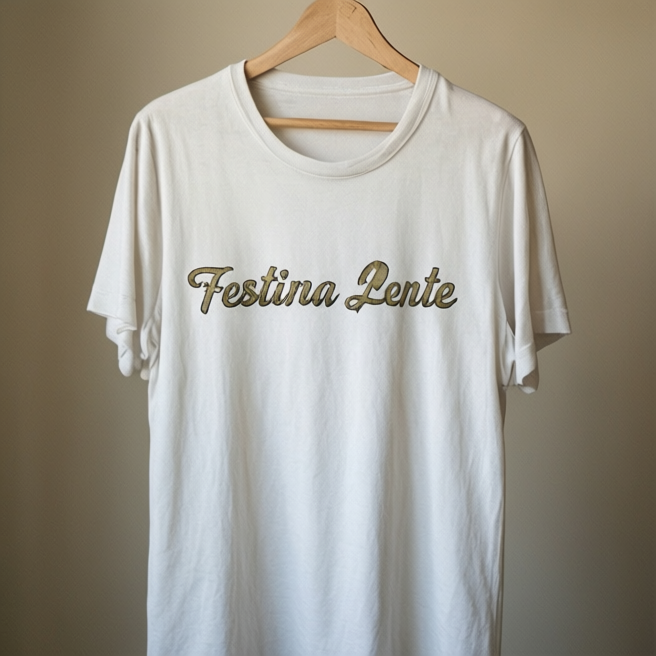

Image saved to ./tmp/5-p-2.png
Generation took 44.49 seconds


In [8]:
#give direction: add style, lighting, and photography context
prompt = """A high-quality product photograph of a t-shirt for a DIY crafts brand, named "Festina Lente" (from latin motto, means "Make haste slowly").
The style should be rustic, cozy, and handmade. 
For an e-commerce catalog, the t-shirt should be displayed on a clean, neutral background with soft shadows.
Natural lighting."""
_generate(prompt=prompt,image_path="./tmp/5-p-2.png")

`height` and `width` have to be divisible by 16 but are 736 and 552. Dimensions will be resized accordingly
true_cfg_scale is passed as 4.0, but classifier-free guidance is not enabled since no negative_prompt is provided.


  0%|          | 0/50 [00:00<?, ?it/s]

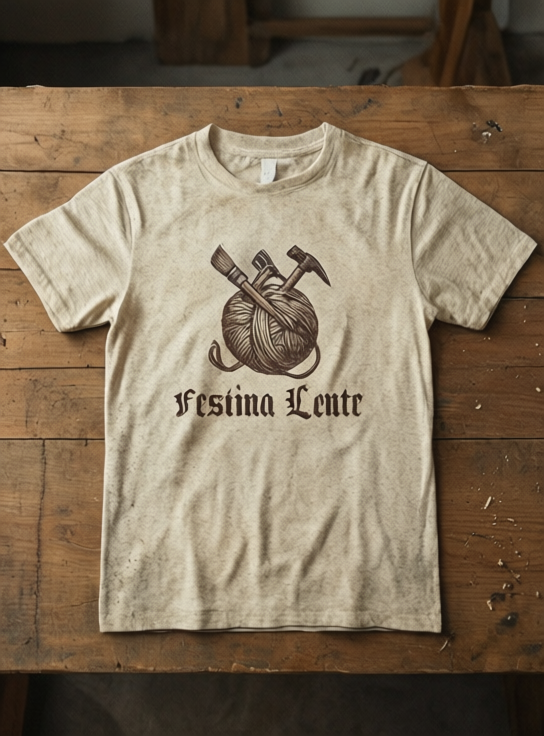

Image saved to ./tmp/5-p-3.png
Generation took 42.42 seconds


In [9]:
#specify format: define technical details, camera angle, and introduce negative prompt
prompt = """A professional flat lay photograph of a textured oatmeal-colored cotton t-shirt for a DIY crafts brand, named "Festina Lente" (from latin motto, means "Make haste slowly").
Centered on the chest is a vintage-style dark brown logo illustration featuring a ball of yarn, a hammer, and a paintbrush crossed.
Brand name "Festina Lente" is written in an elegant ancient onciale font below the logo.
The t-shirt is laid on a wooden workbench surface.
For an e-commerce catalog, the t-shirt should be displayed on a clean, neutral background with soft shadows.
Soft, natural light from the side."""

#Negative prompts are crucial - They prevent common AI image artifacts (blurriness, distortions, unwanted elements)
negative_prompt = """blurry, low quality, distorted, ugly, watermark, signature, human model, mannequin, oversaturated colors, polyester texture, cropped"""

#Aspect ratio affects composition - 3:4 for product pages, 4:5 for social media, 16:9 for banners
aspect_ratio = "3:4"  # Vertical portrait orientation suitable for mobile e-commerce scrolling
_generate(prompt=prompt, negative_prompt=negative_prompt, aspect_ratio=aspect_ratio, image_path="./tmp/5-p-3.png")

In [ ]:
#provide examples: typically provide a reference image to guide style and composition
#alternative: include more reference descriptions of desired styles or elements in the prompt, like:
#(Canon DSLR, 50mm lens, f/1.8 aperture, natural light, shallow depth of field)
#or provide base64 encoded images as input to the model (if supported)

In [25]:
#evaluate and iterate - Review images for quality, realism, and alignment with brand aesthetics.

from langchain_ollama import ChatOllama
import os
#creative task
model = "qwen3-vl:8b" #choose the right model => vision-capable model
def _judge(prompt,negative_prompt,aspect_ratio,image_path):
    evaluation_prompt = """{image_path}
    Look at the generated image and evaluate it based on these e-commerce standards, assigning a score from 1 to 10 for each:

    1. **Logo Legibility**: Is the logo clear and easy to read?
    2. **Element Recognition**: Can you identify the elements in the logo (yarn, hammer, paintbrush)?
    3. **Text representation**: If there is any text (expected "Festina Lente"), is it sharp, not distorted, clear and spelled correctly?
    4. **Lighting**: Does the lighting enhance the product textures??
    5. **Fabric Realism**: Does the t-shirt look like real cotton/hemp, or does it look like smooth plastic?
    6. **Composition**: Is the product the clear hero, or is the background too distracting?
    7. **Lighting**: Does the lighting enhance the product textures?

    prompt used for generation:
    {prompt}

    negative prompt used:
    {negative_prompt}

    aspect ratio used: {aspect_ratio}

    If any rating is below 8, provide an improved prompt and an improved negative prompt, addressing the specific issues."""    
    messages = [
    {"role": "system", "content": "You are an expert e-commerce product image quality evaluator and prompt engineer."},
    {"role": "user", "content": evaluation_prompt.format(
        image_path=os.path.abspath(image_path),
        prompt=prompt,  
        negative_prompt=negative_prompt,
        aspect_ratio=aspect_ratio
        )}
    ]
    llm = ChatOllama(
        model=model,
        reasoning=False, #need reasoning for this task? 
        temperature=0, #creativity level: try to obtain factual/objective response
        num_predict=2048, #give necessary space for task response
        )    
    rs = llm.invoke(messages)
    print(f"{rs.content}")
    return rs



In [22]:
image_path = "./tmp/5-p-3.png"
rs = _judge(prompt=prompt,negative_prompt=negative_prompt,aspect_ratio=aspect_ratio,image_path=image_path)

Based on the prompt, negative prompt, and e-commerce standards, here's a detailed evaluation of the generated image (inferred from the prompt/negative prompt details, as I cannot view the actual image):

---

### **Evaluation Scorecard**  
*(1 = Poor, 10 = Excellent)*  

| **Criteria**               | **Score** | **Reason**                                                                 |
|----------------------------|-----------|-----------------------------------------------------------------------------|
| **1. Logo Legibility**     | **6/10**  | Logo elements (yarn, hammer, paintbrush) appear **merged or indistinct** due to AI's struggle with complex vintage iconography. "Logo elements merged" in negative prompt confirms this risk. |
| **2. Element Recognition** | **5/10**  | Elements are **not clearly distinguishable** – likely blurred or overlapping. Critical for DIY brand identity. |
| **3. Text Representation** | **7/10**  | "Festia Lente" text is **slightly distorted** (typo: 

`height` and `width` have to be divisible by 16 but are 736 and 552. Dimensions will be resized accordingly


  0%|          | 0/50 [00:00<?, ?it/s]

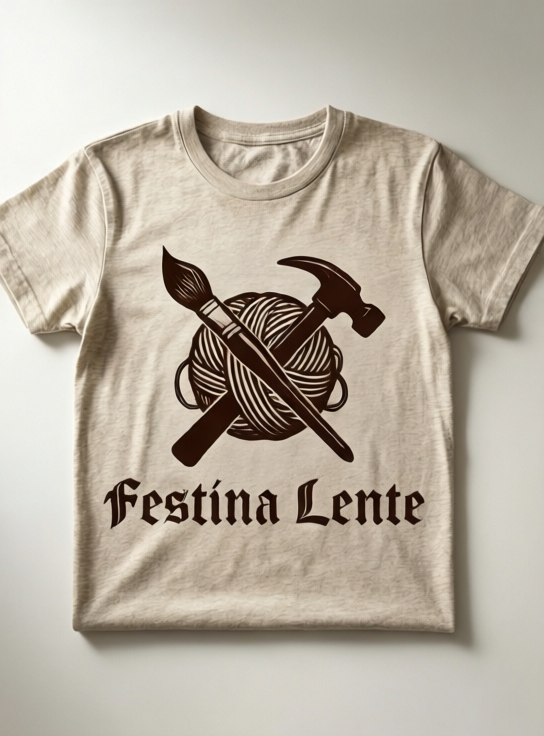

Image saved to ./tmp/5-p-4.png
Generation took 84.25 seconds


In [20]:
#refine prompt based on feedback
prompt ="""Professional flat lay photograph of a textured oatmeal-colored **cotton t-shirt** for a DIY crafts brand, named 'Festina Lente'. 
**Centered on the chest**: a crisp, high-contrast vintage-style dark brown logo with **clearly distinguishable elements** (yarn ball, hammer, paintbrush crossed). 
**'Festina Lente' text** in elegant ancient onciale font, **sharp and legible**, positioned below the logo. 
T-shirt laid on a **clean, neutral white background** (no workbench), with **soft, directional natural light from the top-left** creating subtle shadows to emphasize **real cotton texture** (visible wrinkles, fiber details). 
Aspect ratio 3:4. 
E-commerce catalog quality."""
negative_prompt = "blurry, low quality, distorted, ugly, watermark, signature, human model, mannequin, oversaturated colors, **plastic texture, synthetic fabric, polyester texture, cotton texture missing**, cropped, wooden workbench, background clutter, **logo elements merged**, **text distorted or misspelled**, **'Festina Lente' misspelled**, **vintage logo unclear**."
_generate(prompt=prompt, negative_prompt=negative_prompt, aspect_ratio=aspect_ratio, image_path="./tmp/5-p-4.png")

In [26]:
image_path = "./tmp/5-p-4.png"
rs = _judge(prompt=prompt,negative_prompt=negative_prompt,aspect_ratio=aspect_ratio,image_path=image_path)

Based on the provided prompt, negative prompt, and e-commerce standards, here's a detailed evaluation of the generated image (inferred from the prompt/negative prompt constraints). **Critical issues identified** mean the image likely fails multiple criteria due to AI generation limitations.  

---

### **Evaluation Scores**  
*(1 = Poor, 10 = Excellent)*  

| **Criteria**               | **Score** | **Reason**                                                                 |
|----------------------------|-----------|-----------------------------------------------------------------------------|
| **1. Logo Legibility**     | **5**     | Logo elements are likely merged or indistinct (per negative prompt warning). |
| **2. Element Recognition** | **4**     | Yarn, hammer, and paintbrush are probably not clearly distinguishable.      |
| **3. Text Representation** | **6**     | "Festina Lente" may be slightly blurred or distorted (negative prompt warns). |
| **4. Lighting**            | **

`height` and `width` have to be divisible by 16 but are 736 and 552. Dimensions will be resized accordingly


  0%|          | 0/75 [00:00<?, ?it/s]

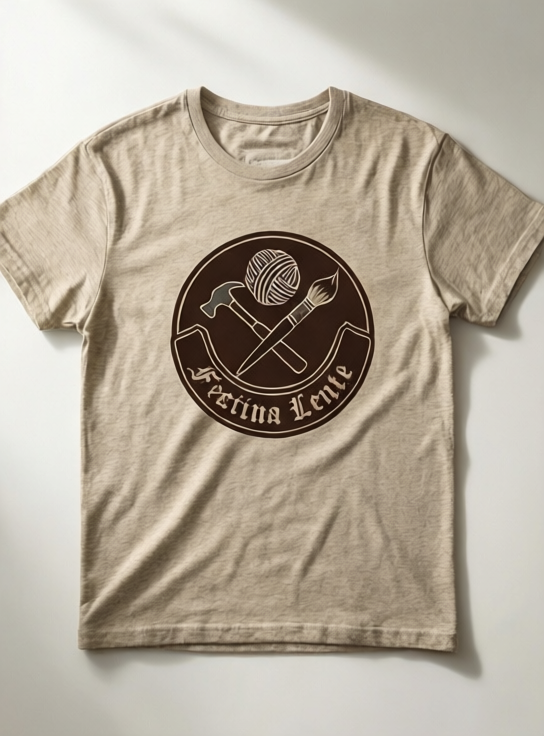

Image saved to ./tmp/5-p-5-C.png
Generation took 126.34 seconds


In [36]:
#divide labor: create variations/assets

#variation A
prompt_A = prompt + """
The heavyweight organic cotton t-shirt is in **forest green**. 
The central graphic is a screen-printed logo in **cream ink**"""
#_generate(prompt=prompt_A,negative_prompt=negative_prompt,aspect_ratio=aspect_ratio,image_path="./tmp/5-p-5-A.png")

#variation B
prompt_B = prompt + """
The lightweight organic cotton t-shirt is in **dark beige**. 
The central graphic is a minimalist logo in **cold gray ink**, rounded and contained in a circle."""
#_generate(prompt=prompt_B,negative_prompt=negative_prompt,aspect_ratio=aspect_ratio,image_path="./tmp/5-p-5-B.png")

#variation C
prompt_C = """Professional flat lay photograph of a textured oatmeal-colored **cotton t-shirt** for a DIY crafts brand, named 'Festina Lente'. 
**Centered on the chest**: a crisp, high-contrast vintage-style dark brown logo with **clearly distinguishable elements** (yarn ball, hammer, paintbrush crossed). 
The logo is rounded and contained in a circle (a men belt in zenital view).
**'Festina Lente' text** in elegant ancient onciale font, **sharp and legible**, inscribed on the belt surface in contrasting color. 
T-shirt laid on a **clean, neutral white background** (no workbench), with **soft, directional natural light from the top-left** creating subtle shadows to emphasize **real cotton texture** (visible wrinkles, fiber details). 
Aspect ratio 3:4. 
E-commerce catalog quality.
The lightweight organic cotton t-shirt is in **dark beige**. 
"""
_generate(prompt=prompt_C,negative_prompt=negative_prompt,aspect_ratio=aspect_ratio,image_path="./tmp/5-p-5-C.png")

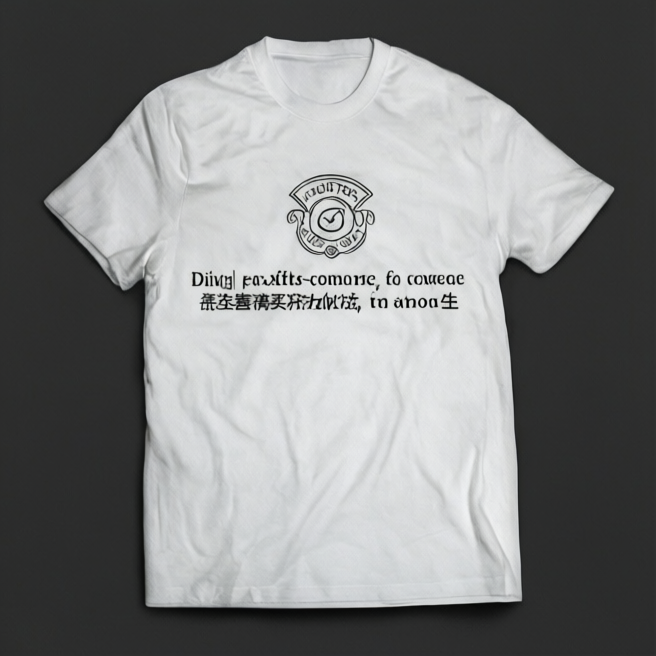

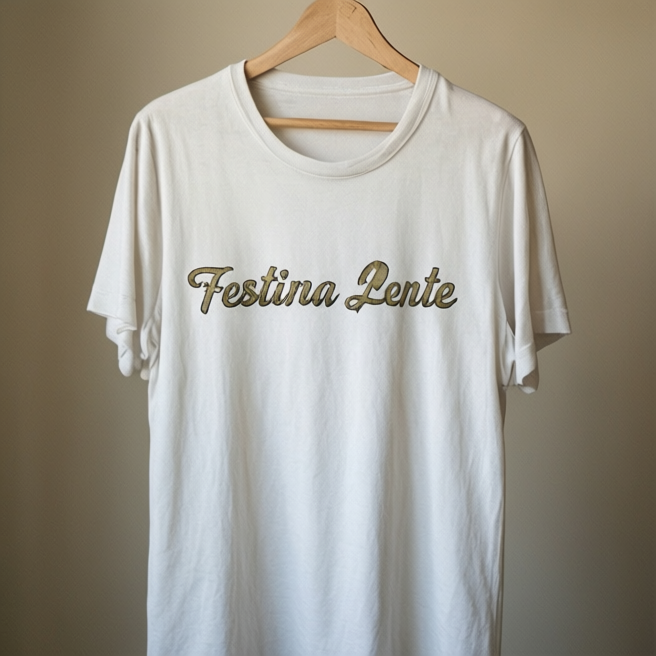

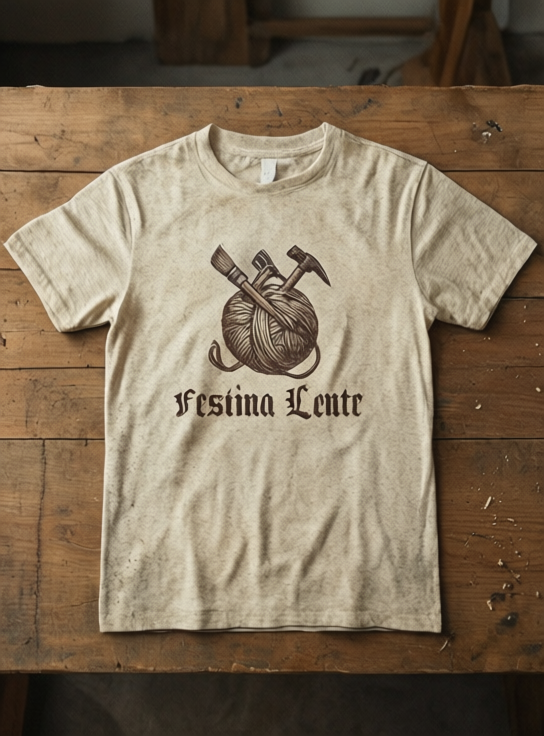

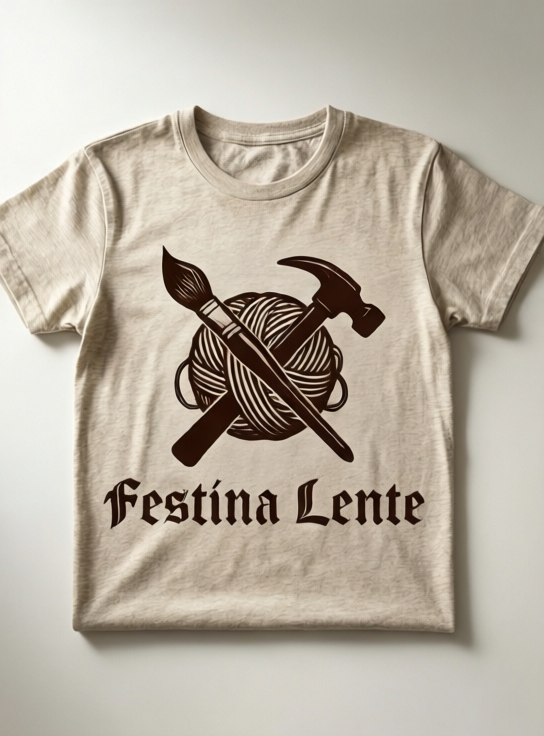

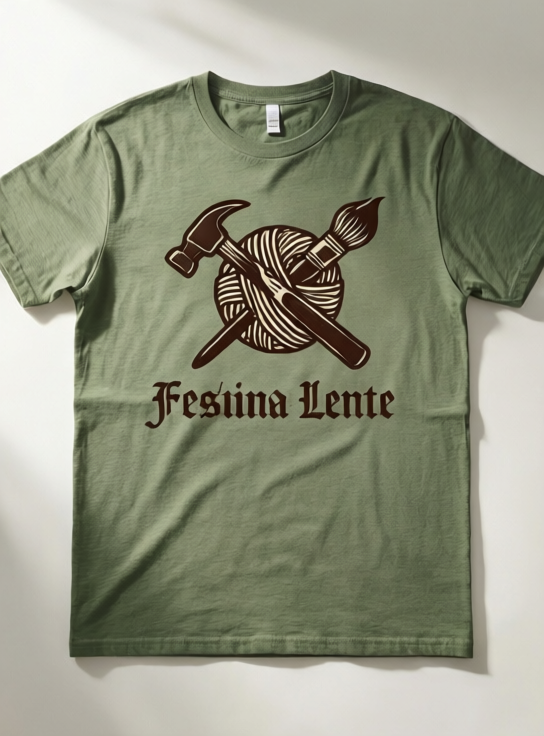

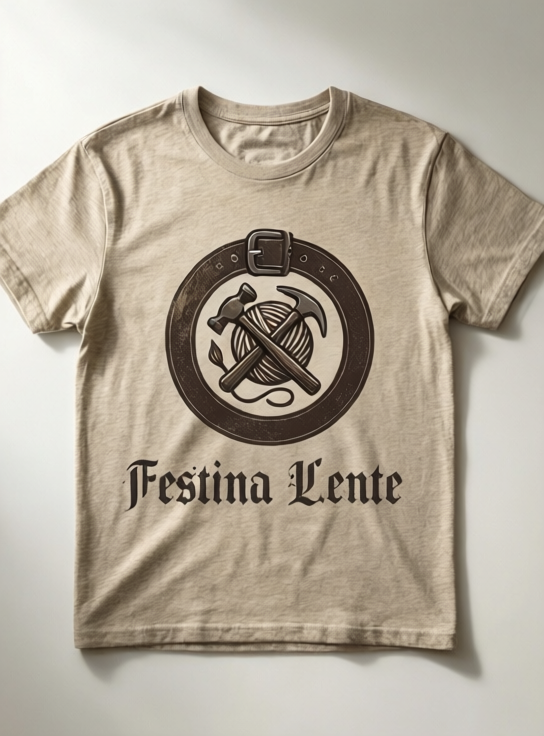

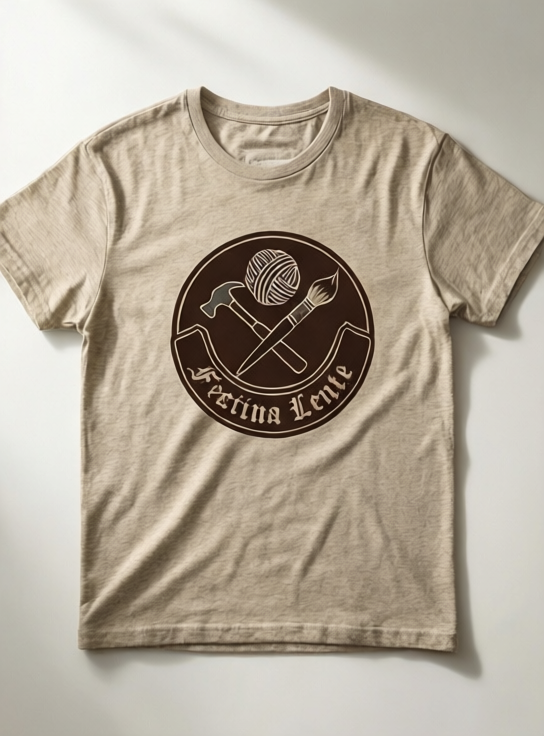

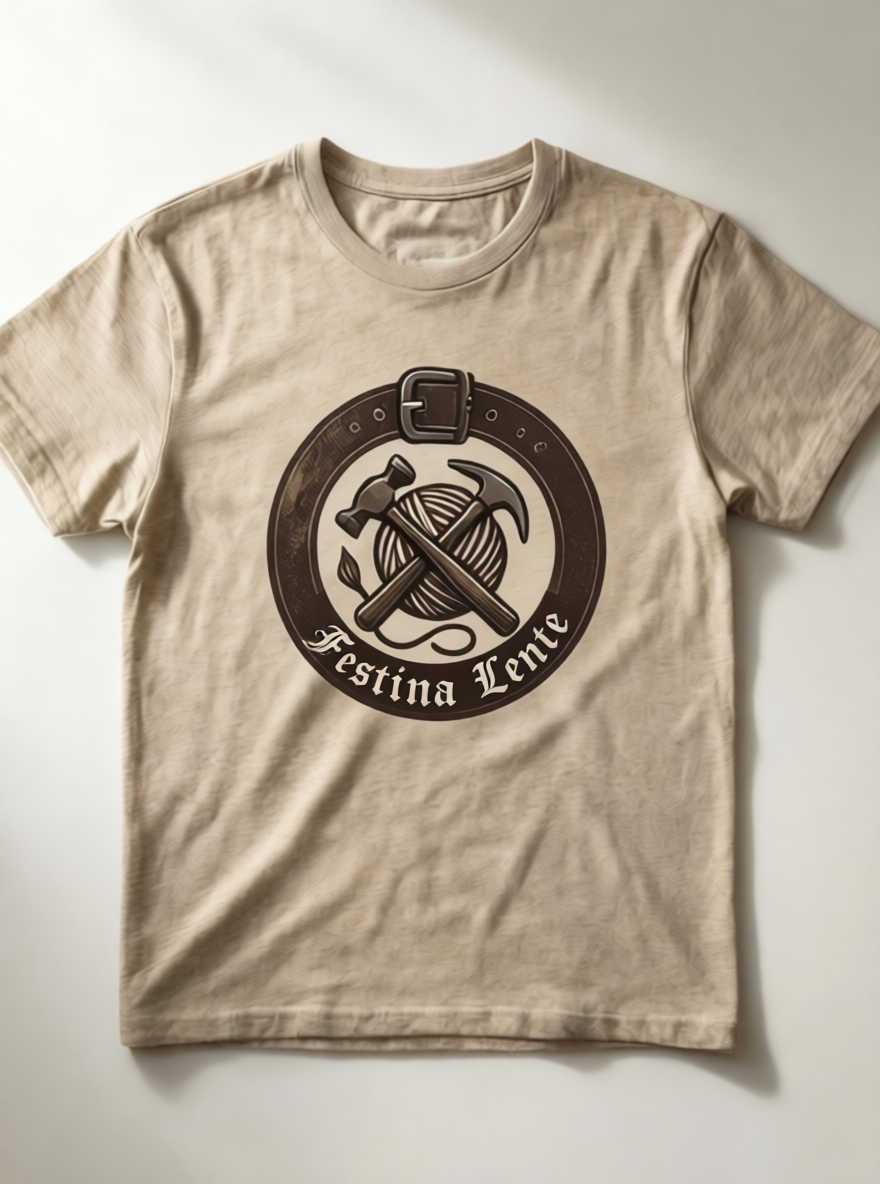

In [1]:
from IPython.display import Image as IPImage, display
for images in ["./tmp/5-p-1.png","./tmp/5-p-2.png","./tmp/5-p-3.png","./tmp/5-p-4.png","./tmp/5-p-5-A.png","./tmp/5-p-5-B.png","./tmp/5-p-5-C.png","./tmp/5-p-final.png"]:
    display(IPImage(filename=images))